In [9]:
from os.path import join
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from ctf_dataset.load import create_wrapped_dataset

In [3]:
base_dir = '/jukebox/hasson/snastase/social-ctf'
data_dir = join(base_dir, 'data_v1')
wrap_f = create_wrapped_dataset(data_dir, output_dataset_name="virtual.hdf5")

In [4]:
map_id, matchup_id, repeat_id, player_id = 0, 0, 0, 0
actions = wrap_f['map/matchup/repeat/player/time/action'][
    map_id, matchup_id, repeat_id, player_id].T

/jukebox/hasson/snastase/miniconda3/envs/ctf/lib/python3.7/site-packages/scipy/stats/stats.py:2500: RuntimeWarning: invalid value encountered in true_divide
  return (a - mns) / sstd


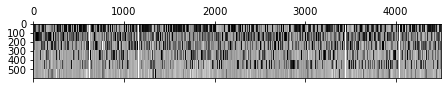

In [5]:
fig, ax = plt.subplots(figsize=(12, 1))
ax.matshow(np.repeat(zscore(actions), 100, axis=0),
           cmap='binary')

NameError: name 'lstms_pc' is not defined

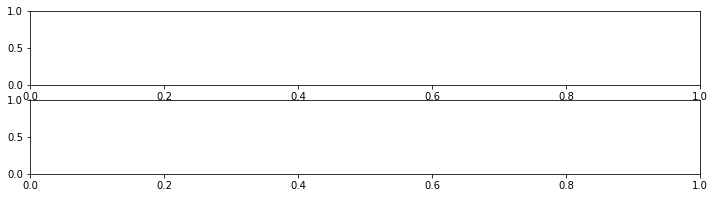

In [6]:
    fig, axs = plt.subplots(2, 1, figsize=(12, 3))
    axs[0].plot(lstms_pc[0], c='darkred', alpha=.7)
    axs[0].plot(lstms_pc[1], c='coral', alpha=.7)
    axs[0].set(xticks=[], ylabel='activation', xlim=(0, 4500))
    axs[0].set_title(f'PC{pc_id + 1} (map {map_id}, repeat {repeat_id})')
    axs[0].annotate(f'ISC: {pearsonr(lstms_pc[0], lstms_pc[1])[0]:.3f}', (.99, 1),
                    ha='right', va='bottom', xycoords='axes fraction')
    axs[1].plot(lstms_pc[2], c='darkblue', alpha=.7)
    axs[1].plot(lstms_pc[3], c='lightseagreen', alpha=.7)
    axs[1].set(xticks=[], ylabel='activation', xlim=(0, 4500))
    axs[1].annotate(f'ISC: {pearsonr(lstms_pc[2], lstms_pc[3])[0]:.3f}', (.99, 1),
                    ha='right', va='bottom', xycoords='axes fraction')
    sns.despine()

In [25]:
n_samples = 4501
map_id, matchup_id, repeat_id = 0, 0, 0
reward = wrap_f[f'map/matchup/repeat/player/time/reward'][map_id, matchup_id, repeat_id]
red_score = wrap_f[f'map/matchup/repeat/time/red_team_score'][map_id, matchup_id, repeat_id]
blue_score = wrap_f[f'map/matchup/repeat/time/blue_team_score'][map_id, matchup_id, repeat_id]

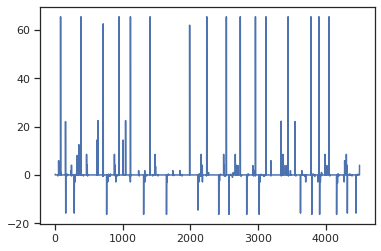

In [38]:
from scipy.stats import zscore

In [45]:
scores /= np.amax(scores)

TypeError: No loop matching the specified signature and casting was found for ufunc true_divide

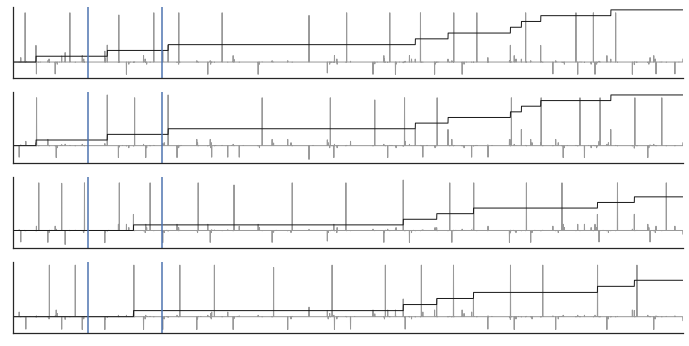

In [56]:
n_samples = 4501
map_id, matchup_id, repeat_id = 0, 0, 0

reward = wrap_f[f'map/matchup/repeat/player/time/reward'][map_id, matchup_id, repeat_id]
reward = reward / np.amax(reward)

red_score = wrap_f[f'map/matchup/repeat/time/red_team_score'][map_id, matchup_id, repeat_id]
blue_score = wrap_f[f'map/matchup/repeat/time/blue_team_score'][map_id, matchup_id, repeat_id]
#scores = np.hstack((red_score, red_score, blue_score, blue_score)).T
scores = np.hstack((blue_score, blue_score, red_score, red_score)).T
scores = scores / np.amax(scores)

sns.set(style='ticks', font_scale=1)
fig, axs = plt.subplots(4, 1, figsize=(12, 6))
for ts, sc, ax in zip(reward, scores, axs):
    ax.plot(ts, lw=1, c='.6')
    ax.plot(sc, lw=1, c='.1')
    ax.set(xticks=[], yticks=[], xlim=(0, n_samples - 1))
    ax.axvline(500)
    ax.axvline(1000)
    #ax.set_ylabel(r, rotation=0, ha='right', va='center')
    sns.despine()

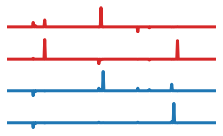

In [86]:
begin, end = 580, 870
map_id, matchup_id, repeat_id = 0, 0, 0

reward = wrap_f[f'map/matchup/repeat/player/time/reward'][map_id, matchup_id, repeat_id]
reward = reward / np.amax(reward)

red_score = wrap_f[f'map/matchup/repeat/time/red_team_score'][map_id, matchup_id, repeat_id]
blue_score = wrap_f[f'map/matchup/repeat/time/blue_team_score'][map_id, matchup_id, repeat_id]
#scores = np.hstack((red_score, red_score, blue_score, blue_score)).T
scores = np.hstack((blue_score, blue_score, red_score, red_score)).T
scores = scores / np.amax(scores)

reward = reward[:, begin:end]
scores = scores[:, begin:end]
colors = ['tab:red', 'tab:red', 'tab:blue', 'tab:blue']
#colors = ['darkred', 'salmon', 'darkblue', 'tab:blue']

sns.set(style='ticks', font_scale=1)
fig, axs = plt.subplots(4, 1, figsize=(3.75, 2.25))
for ts, c, ax in zip(reward, colors, axs):
    ax.plot(ts, lw=3, c=c)
    #ax.plot(sc, lw=1, c='.1')
    ax.axis('off')
    ax.set(xticks=[], yticks=[], xlim=(0, end - begin))
    #ax.set_ylabel(r, rotation=0, ha='right', va='center')
    sns.despine()
    plt.savefig(f'figures/reward_ts.svg', dpi=300, bbox_inches='tight', transparent=True)

In [ ]:
sns.set(style='ticks', font_scale=1)
fig, axs = plt.subplots(5, 1, figsize=(6, 3))
for r, ax in zip(relations, axs):
    ts = wrap_f[f'map/matchup/repeat/player/time/{relations[r]}'][
        map_id, matchup_id, repeat_id, player_id][..., :2]
    if r == 'velocity':
        ts = np.clip(ts, -np.std(ts) ** 2.58, np.std(ts) ** 2.58) 
    if ts.ndim == 3:
        ts = ts[0]
    ax.plot(ts, lw=1, c='.6')
    ax.set(xticks=[], yticks=[], xlim=(0, n_samples - 1))
    ax.set_ylabel(r, rotation=0, ha='right', va='center')
    sns.despine()
ax.set_xticks(np.arange(0, n_samples, 500))
ax.set_xticklabels([])
plt.savefig(f'figures/behav-relations_data-v1_trace.svg', dpi=300, bbox_inches='tight', transparent=True)

In [133]:
map_id, matchup_id, repeat_id, player_id = 0, 0, 0, 3
start, end = 0, 150
frames = wrap_f["map/matchup/repeat/player/time/pov"][
    map_id, matchup_id, repeat_id, player_id, start:end].astype(np.uint8)

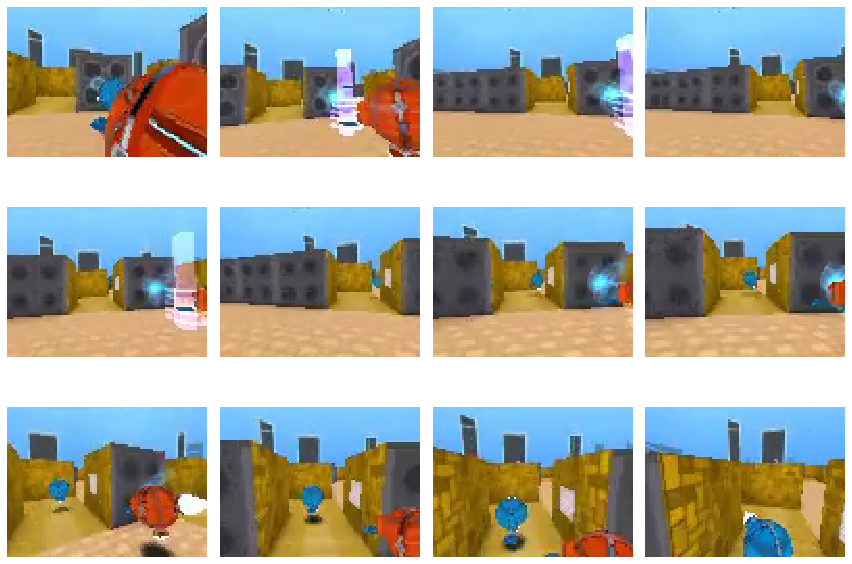

In [140]:
start_frame = 40
frame_ids = np.arange(start_frame, start_frame + 12)

fig, axs = plt.subplots(3, 4, figsize=(12, 9))
for ax, f in zip(axs.ravel(), frames[frame_ids]):
    ax.matshow(f)
    ax.axis('off')
plt.tight_layout()

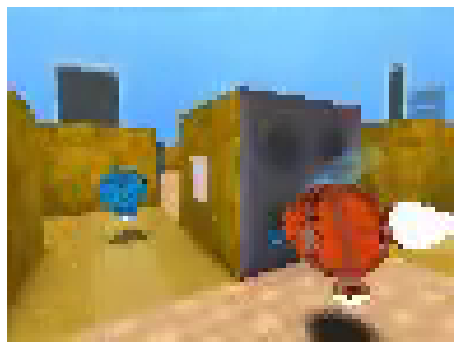

In [154]:
frame_id = 48

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(frames[frame_id])
ax.axis('off')
plt.savefig(f'figures/pov_frame.png', dpi=300, bbox_inches='tight', transparent=True)

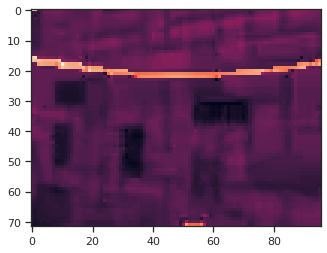

In [98]:
plt.imshow(f[..., 0])

In [94]:
f[..., 0].shape

(72, 96)

In [231]:
n_samples = 4501
map_id, matchup_id, repeat_id = 0, 0, 5

position = wrap_f[f'map/matchup/repeat/player/time/position'][map_id, matchup_id, repeat_id]
actions = wrap_f[f'map/matchup/repeat/player/time/action'][map_id, matchup_id, repeat_id]

In [230]:
actions.shape

(4, 4501, 6)

In [235]:
np.where(actions[2, :, 4] == 1, 1, np.nan)

array([nan, nan, nan, ..., nan,  1., nan])

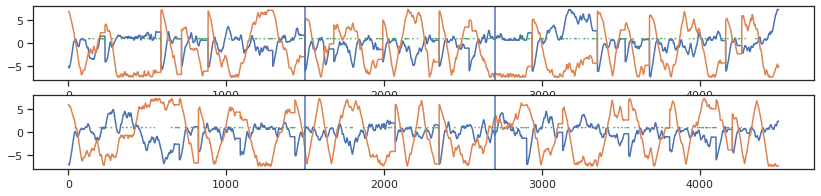

In [236]:
fig, axs = plt.subplots(2, 1, figsize=(14, 3))

p1b1, p1b2 = position[2, :, 0], position[2, :, 1]
p2b1, p2b2 = position[3, :, 0], position[3, :, 1]
p1b3 = np.where(actions[2, :, 4] == 1, 1, np.nan)
p2b3 = np.where(actions[3, :, 4] == 1, 1, np.nan)

#start, end = 3700, 4300
start, end = 500, 1250
start, end = 1500, 2700

axs[0].plot(p1b1)
axs[0].plot(p1b2)
axs[0].plot(p1b3)
axs[0].axvline(start)
axs[0].axvline(end)
axs[1].plot(p2b1)
axs[1].plot(p2b2)
axs[1].plot(p2b3)
axs[1].axvline(start)
axs[1].axvline(end)
#axs[2].plot(zscore(p1) * zscore(p2))

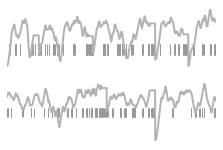

In [268]:
fig, axs = plt.subplots(2, 1, figsize=(3.75, 2.5))

axs[0].plot(zscore(p1b1[start:end]), lw=2, c='.7')
#axs[0].plot(zscore(p1b2[start:end]) - 2, lw=2, c='.8')
axs[0].vlines(np.where(p1b3[start:end] == 1)[0], -2, -1, lw=1, color='.6')
axs[0].axis('off')
axs[0].set(xticks=[], yticks=[], xlim=(0, end - start))
axs[1].plot(zscore(p2b1[start:end]), lw=2, c='.7')
#axs[1].plot(zscore(p2b2[start:end]) - 2, lw=2, c='.8')
axs[1].vlines(np.where(p2b3[start:end] == 1)[0], -2, -1, lw=1, color='.6')
axs[1].axis('off')
axs[1].set(xticks=[], yticks=[], xlim=(0, end - start))
plt.savefig(f'figures/behav_example_ts.svg', dpi=300, bbox_inches='tight', transparent=True)

In [244]:
p2b3[start:end]

array([ 1., nan, nan, ..., nan, nan, nan])

In [245]:
np.where(p2b3[start:end] == 1)[0]

array([   0,    4,   19,   20,   21,   23,   87,   88,  136,  137,  138,
        151,  210,  211,  234,  236,  258,  259,  286,  287,  288,  290,
        291,  295,  298,  299,  344,  346,  348,  368,  369,  370,  371,
        372,  373,  394,  395,  428,  429,  430,  431,  432,  454,  455,
        456,  471,  480,  481,  482,  483,  484,  487,  505,  506,  507,
        508,  509,  513,  514,  515,  517,  529,  530,  531,  532,  533,
        535,  536,  541,  544,  547,  548,  549,  555,  559,  563,  567,
        568,  569,  570,  578,  601,  602,  604,  646,  648,  649,  650,
        651,  653,  672,  673,  674,  675,  676,  681,  713,  714,  715,
        716,  717,  718,  719,  721,  722,  723,  724,  725,  726,  727,
        729,  730,  731,  732,  733,  775,  777,  778,  808,  809,  810,
        812,  813,  826,  828,  829,  830,  835,  836,  837,  838,  840,
        841,  842,  845,  846,  847,  848,  946,  947,  948,  949, 1053,
       1055, 1077, 1078, 1080, 1082, 1102, 1103, 11

In [242]:
ax.vlines?

Signature:
ax.vlines(
    x,
    ymin,
    ymax,
    colors=None,
    linestyles='solid',
    label='',
    *,
    data=None,
    **kwargs,
)
Docstring:
Plot vertical lines.

Plot vertical lines at each *x* from *ymin* to *ymax*.

Parameters
----------
x : float or array-like
    x-indexes where to plot the lines.

ymin, ymax : float or array-like
    Respective beginning and end of each line. If scalars are
    provided, all lines will have same length.

colors : list of colors, default: :rc:`lines.color`

linestyles : {'solid', 'dashed', 'dashdot', 'dotted'}, optional

label : str, default: ''

Returns
-------
`~matplotlib.collections.LineCollection`

Other Parameters
----------------
**kwargs : `~matplotlib.collections.LineCollection` properties.

See Also
--------
hlines : horizontal lines
axvline: vertical line across the axes

Notes
-----


.. note::
    In addition to the above described arguments, this function can take
    a *data* keyword argument. If such a *data* argument i

In [270]:
lstm_pcs = np.load(f'results/lstms-pca_matchup-{matchup_id}_map-{map_id}_repeat-{repeat_id}.npy')

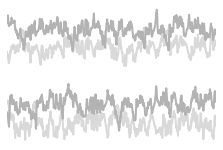

In [286]:
fig, axs = plt.subplots(2, 1, figsize=(3.75, 2.5))

p1l1 = lstm_pcs[2,:, 5]
p1l2 = lstm_pcs[2,:, 7]

p2l1 = lstm_pcs[3,:, 5]
p2l2 = lstm_pcs[3,:, 7]

axs[0].plot(zscore(p1l2[start:end]) - 2.5, lw=2, c='.85')
axs[0].plot(zscore(p1l1[start:end]), lw=2, c='.7')
axs[0].axis('off')
axs[0].set(xticks=[], yticks=[], xlim=(0, end - start))
axs[1].plot(zscore(p2l2[start:end]) - 2.5, lw=2, c='.85')
axs[1].plot(zscore(p2l1[start:end]), lw=2, c='.7')
axs[1].axis('off')
axs[1].set(xticks=[], yticks=[], xlim=(0, end - start))
plt.savefig(f'figures/lstm-pc_example_ts.svg', dpi=300, bbox_inches='tight', transparent=True)